In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("EDA Phase Started")

EDA Phase Started


In [2]:
df = pd.read_csv(
    "../data/processed/multilingual_sentiment.csv"
)

print(df.shape)
df.head()

(30878, 3)


,text,sentiment,language
0,"Next date - Birmingham, The Rainbow, Sun 7th J...",Positive,English
1,Action king dialogue semma..... avanoda sindh...,Positive,Tamil
2,"Appedilaam nadekaathu, nadake kudaathu!! The ...",Positive,Tamil
3,Looks like d Mixture of Kaala+Kabali..... ...,Positive,Tamil
4,Nfg greatest hits cd cracked,Negative,English


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30878 entries, 0 to 30877
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       30878 non-null  object
 1   sentiment  30878 non-null  object
 2   language   30878 non-null  object
dtypes: object(3)
memory usage: 723.8+ KB


In [4]:
df.isnull().sum()

text         0
sentiment    0
language     0
dtype: int64

In [5]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 92


In [6]:
df["language"].value_counts()

language
English    20000
Tamil       9075
Hindi       1803
Name: count, dtype: int64

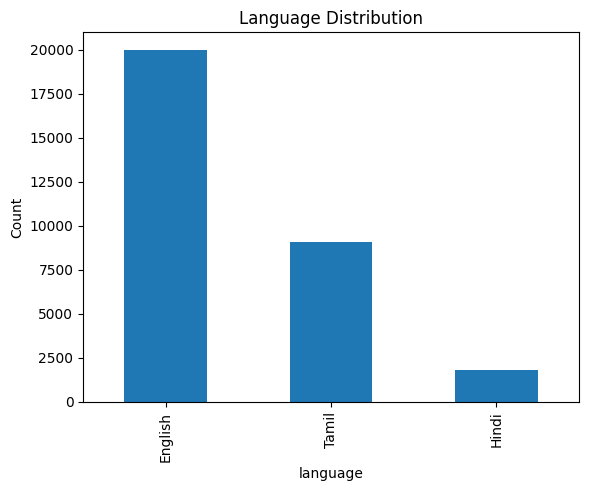

In [7]:
df["language"].value_counts().plot(
    kind="bar"
)

plt.title("Language Distribution")
plt.ylabel("Count")
plt.show()

In [8]:
df["sentiment"].value_counts()

sentiment
Positive    18640
Negative    12238
Name: count, dtype: int64

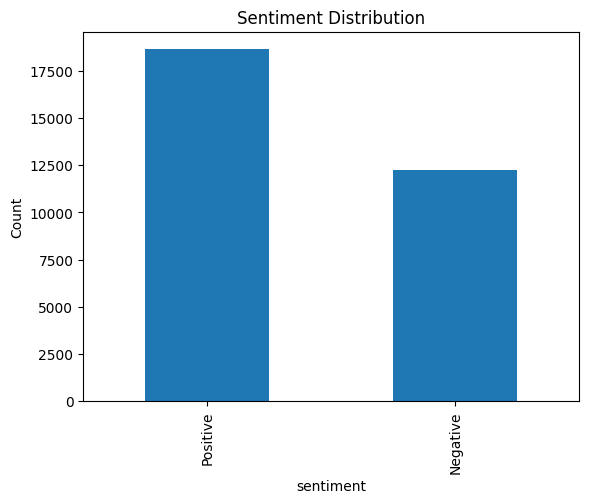

In [9]:
df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.ylabel("Count")
plt.show()

In [10]:
df["text_length"] = df["text"].astype(str).apply(len)

df["text_length"].describe()

count    30878.000000
mean        66.957996
std         34.504268
min          5.000000
25%         39.000000
50%         59.000000
75%         90.000000
max        514.000000
Name: text_length, dtype: float64

In [11]:
df.groupby(
    "language"
)["text_length"].mean()

language
English    74.267550
Hindi      33.054354
Tamil      57.584683
Name: text_length, dtype: float64

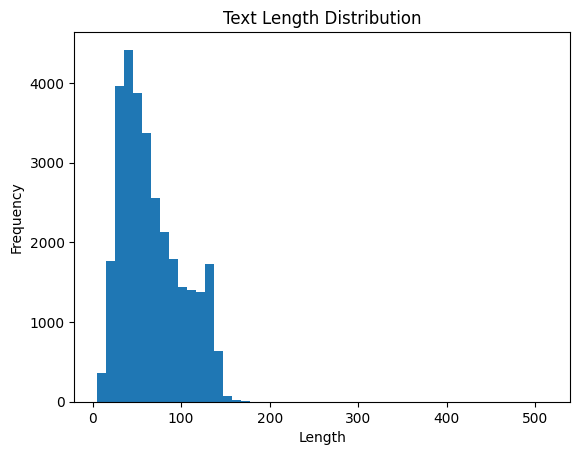

In [12]:
plt.hist(
    df["text_length"],
    bins=50
)

plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

In [13]:
pd.crosstab(
    df["language"],
    df["sentiment"]
)

sentiment,Negative,Positive
language,,
English,9942,10058
Hindi,848,955
Tamil,1448,7627


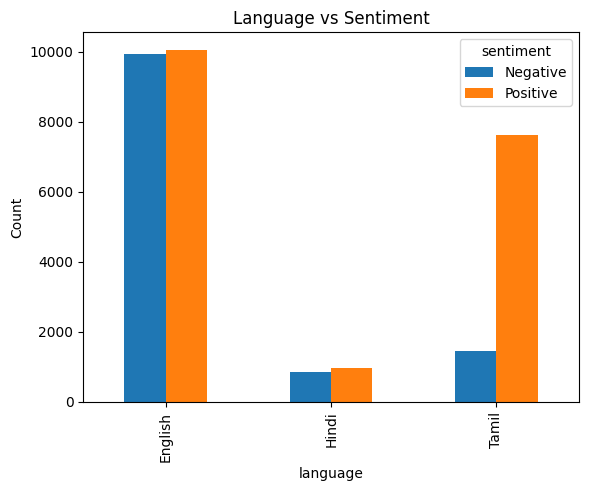

In [14]:
pd.crosstab(
    df["language"],
    df["sentiment"]
).plot(kind="bar")

plt.title("Language vs Sentiment")
plt.ylabel("Count")

plt.show()

In [15]:
df_clean = df.drop_duplicates()

print("Before:", df.shape)
print("After :", df_clean.shape)

Before: (30878, 4)
After : (30786, 4)


In [16]:
df.nlargest(
    5,
    "text_length"
)[["language", "sentiment", "text_length", "text"]]

,language,sentiment,text_length,text
28147,Tamil,Positive,514,Thalaaaaaaaaaaaaaa aaaaaaaaaaaaaaaaaaaaaaaaaa...
8410,Tamil,Positive,302,can not wait for thala movie ...................
18877,Tamil,Positive,272,#NerKondaPaarvaiTrailer #NerKondaPaarvaiTrai...
21304,Tamil,Positive,241,"what a trailer, thalaivaaaaaaaaaaaaaaaaaaaaaa..."
12712,Tamil,Positive,240,Super star..naa. super star..thaaa.. marana w...


In [17]:
df.nsmallest(
    5,
    "text_length"
)[
    ["language",
     "sentiment",
     "text_length",
     "text"]
]

,language,sentiment,text_length,text
1790,Tamil,Positive,5,Nice
13359,Tamil,Positive,6,Semma
27963,Tamil,Positive,6,Thala
30771,Tamil,Positive,6,Thala
4861,English,Negative,8,P.e now


In [18]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


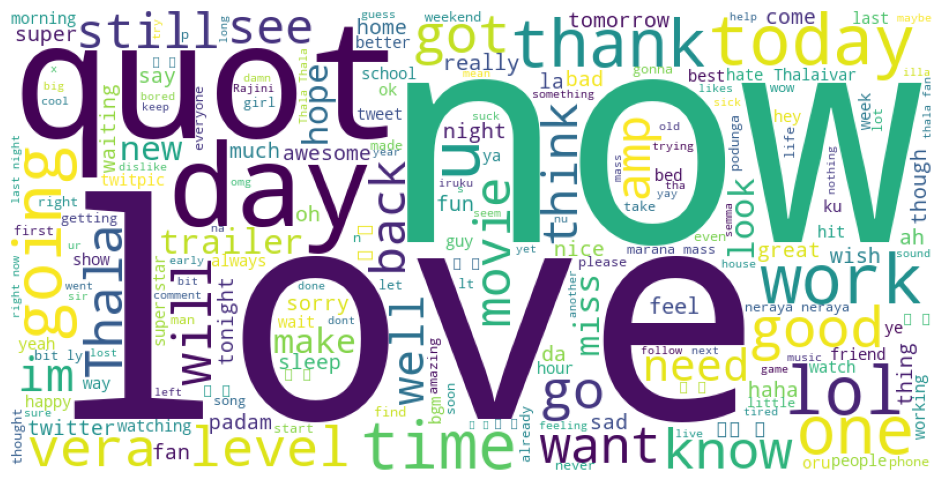

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(
    df["text"].astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [20]:
from collections import Counter

words = " ".join(
    df["text"].astype(str)
).split()

top_words = Counter(words).most_common(20)

top_words

[('to', 7102),
 ('I', 6415),
 ('the', 6204),
 ('a', 4883),
 ('and', 3618),
 ('my', 3505),
 ('i', 3132),
 ('you', 3005),
 ('is', 2918),
 ('for', 2865),
 ('in', 2662),
 ('it', 2228),
 ('of', 2212),
 ('like', 2041),
 ('on', 1987),
 ('have', 1639),
 ('so', 1567),
 ('me', 1533),
 ('but', 1460),
 ('that', 1459)]

In [21]:
top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,to,7102
1,I,6415
2,the,6204
3,a,4883
4,and,3618
5,my,3505
6,i,3132
7,you,3005
8,is,2918
9,for,2865
